In [ ]:
from google.colab import files

uploaded = files.upload()

Saving machinelearninginaction-master.zip to machinelearninginaction-master.zip


In [ ]:
import zipfile
import os

zip_file = list(uploaded.keys())[0]

with zipfile.ZipFile(zip_file, 'r') as zip_ref:
    zip_ref.extractall('/content')

print("Extracted successfully!")

Extracted successfully!


In [ ]:
import os

for root, dirs, files in os.walk("/content"):
    if "trainingDigits" in dirs or "testDigits" in dirs:
        print("Found:", root)
        print("Folders:", dirs)

In [ ]:
base_path = "/content/machinelearninginaction-master/Ch02"

print(os.listdir(base_path))

['datingTestSet.txt', 'kNN.py', 'EXTRAS', 'datingTestSet2.txt', 'digits.zip', 'README.txt']


In [ ]:
import numpy as np

def img2vector(filename):
    vector = np.zeros((1, 1024))

    with open(filename, 'r') as file:
        for i in range(32):
            line = file.readline()

            for j in range(32):
                vector[0, 32 * i + j] = int(line[j])

    return vector

In [ ]:
import zipfile

# Path to digits.zip
digits_zip_path = os.path.join(base_path, "digits.zip")

# Extract digits.zip into the base_path directory
with zipfile.ZipFile(digits_zip_path, 'r') as zip_ref:
    zip_ref.extractall(base_path)

print(f"Extracted {digits_zip_path} to {base_path}")

Extracted /content/machinelearninginaction-master/Ch02/digits.zip to /content/machinelearninginaction-master/Ch02


In [ ]:
training_path = os.path.join(base_path, "trainingDigits")

training_files = os.listdir(training_path)

training_data = []
training_labels = []

for filename in training_files:

    # Example filename: 5_12.txt
    label = int(filename.split("_")[0])

    training_labels.append(label)

    vector = img2vector(
        os.path.join(training_path, filename)
    )

    training_data.append(vector[0])

training_data = np.array(training_data)
training_labels = np.array(training_labels)

print("Training samples:", len(training_data))
print("Training data shape:", training_data.shape)

Training samples: 1934
Training data shape: (1934, 1024)


In [ ]:
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(n_neighbors=3)

knn.fit(training_data, training_labels)

print("kNN model trained successfully!")

kNN model trained successfully!


In [ ]:
test_path = os.path.join(base_path, "testDigits")

test_files = os.listdir(test_path)

correct = 0

for filename in test_files:

    actual_label = int(filename.split("_")[0])

    vector = img2vector(
        os.path.join(test_path, filename)
    )

    predicted_label = knn.predict(vector)[0]

    if predicted_label == actual_label:
        correct += 1

accuracy = correct / len(test_files)

print("Total test samples:", len(test_files))
print("Correct predictions:", correct)
print("Accuracy:", accuracy * 100, "%")

Total test samples: 946
Correct predictions: 934
Accuracy: 98.73150105708245 %


In [ ]:
import random

filename = random.choice(test_files)

vector = img2vector(
    os.path.join(test_path, filename)
)

actual = int(filename.split("_")[0])
predicted = knn.predict(vector)[0]

print("File:", filename)
print("Actual digit:", actual)
print("Predicted digit:", predicted)

File: 0_5.txt
Actual digit: 0
Predicted digit: 0


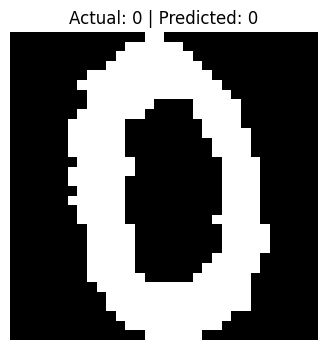

In [ ]:
import matplotlib.pyplot as plt

image = vector.reshape(32, 32)

plt.figure(figsize=(4, 4))
plt.imshow(image, cmap="gray")
plt.title(f"Actual: {actual} | Predicted: {predicted}")
plt.axis("off")
plt.show()

In [ ]:
from google.colab import files

uploaded = files.upload()

Saving knn_brightness_saturation.csv to knn_brightness_saturation.csv


In [ ]:
import pandas as pd
import numpy as np

df = pd.read_csv("knn_brightness_saturation.csv")

print("Dataset:")
display(df)

Dataset:


,Brightness,Saturation,Class
0,40,20,Red
1,50,50,Blue
2,60,90,Blue
3,10,25,Red
4,70,70,Blue
5,60,10,Red
6,25,80,Blue


In [ ]:
new_brightness = 20
new_saturation = 35

print("New Entry")
print("Brightness:", new_brightness)
print("Saturation:", new_saturation)

New Entry
Brightness: 20
Saturation: 35


In [ ]:
df["Distance"] = np.sqrt(
    (df["Brightness"] - new_brightness) ** 2 +
    (df["Saturation"] - new_saturation) ** 2
)

display(df)

,Brightness,Saturation,Class,Distance
0,40,20,Red,25.000000
1,50,50,Blue,33.541020
2,60,90,Blue,68.007353
3,10,25,Red,14.142136
4,70,70,Blue,61.032778
5,60,10,Red,47.169906
6,25,80,Blue,45.276926


In [ ]:
sorted_df = df.sort_values("Distance")

display(sorted_df)

,Brightness,Saturation,Class,Distance
3,10,25,Red,14.142136
0,40,20,Red,25.000000
1,50,50,Blue,33.541020
6,25,80,Blue,45.276926
5,60,10,Red,47.169906
4,70,70,Blue,61.032778
2,60,90,Blue,68.007353


In [ ]:
nearest = sorted_df.iloc[0]

print("Nearest Entry")
print("----------------")
print("Brightness:", nearest["Brightness"])
print("Saturation:", nearest["Saturation"])
print("Class:", nearest["Class"])
print("Distance:", nearest["Distance"])

Nearest Entry
----------------
Brightness: 10
Saturation: 25
Class: Red
Distance: 14.142135623730951


In [ ]:
from sklearn.neighbors import KNeighborsClassifier

X = df[["Brightness", "Saturation"]]
y = df["Class"]

knn = KNeighborsClassifier(n_neighbors=3)

knn.fit(X, y)

prediction = knn.predict(
    [[new_brightness, new_saturation]]
)

print("New Entry:")
print("Brightness:", new_brightness)
print("Saturation:", new_saturation)
print("Predicted Class:", prediction[0])

New Entry:
Brightness: 20
Saturation: 35
Predicted Class: Red


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but KNeighborsClassifier was fitted with feature names
  warnings.warn(
